<a href="https://colab.research.google.com/github/PRASHANTH6215/RANDOM_FOREST_ML/blob/main/RANDOM_FOREST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gradio

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.impute import SimpleImputer


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    'pregnancies','glucose','bloodpressure','skinthickness','insulin','bmi','diabetespedigreefunction','age','outcome'
]
df = pd.read_csv(url,names=columns)
print(df.head())

   pregnancies  glucose  bloodpressure  skinthickness  insulin   bmi  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   diabetespedigreefunction  age  outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum)


(768, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pregnancies               768 non-null    int64  
 1   glucose                   768 non-null    int64  
 2   bloodpressure             768 non-null    int64  
 3   skinthickness             768 non-null    int64  
 4   insulin                   768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   diabetespedigreefunction  768 non-null    float64
 7   age                       768 non-null    int64  
 8   outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
       pregnancies     glucose  bloodpressure  skinthickness     insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479  

In [ ]:
cols = ['pregnancies','glucose','bloodpressure','skinthickness','insulin','bmi']
im = SimpleImputer(missing_values=np.nan,strategy='mean')
for col in cols:
  df[col] = im.fit_transform(df[col].values.reshape(-1,1))
print(df.isnull().sum)

<bound method DataFrame.sum of      pregnancies  glucose  bloodpressure  skinthickness  insulin    bmi  \
0          False    False          False          False    False  False   
1          False    False          False          False    False  False   
2          False    False          False          False    False  False   
3          False    False          False          False    False  False   
4          False    False          False          False    False  False   
..           ...      ...            ...            ...      ...    ...   
763        False    False          False          False    False  False   
764        False    False          False          False    False  False   
765        False    False          False          False    False  False   
766        False    False          False          False    False  False   
767        False    False          False          False    False  False   

     diabetespedigreefunction    age  outcome  
0                   

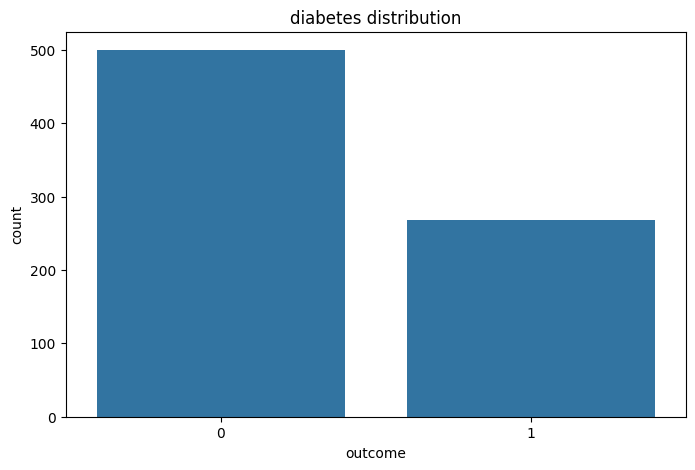

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='outcome',data=df)
plt.title("diabetes distribution")
plt.show()

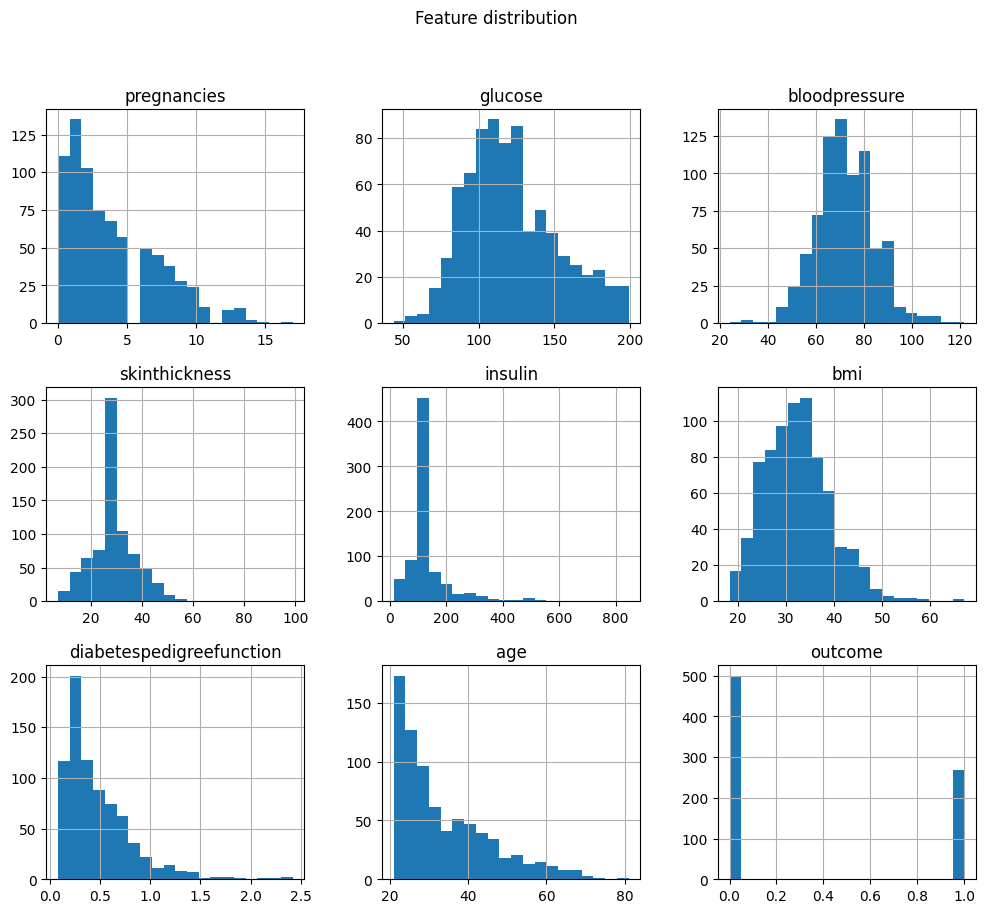

In [ ]:
df.hist(figsize=(12,10),bins = 20)
plt.suptitle("Feature distribution")
plt.show()

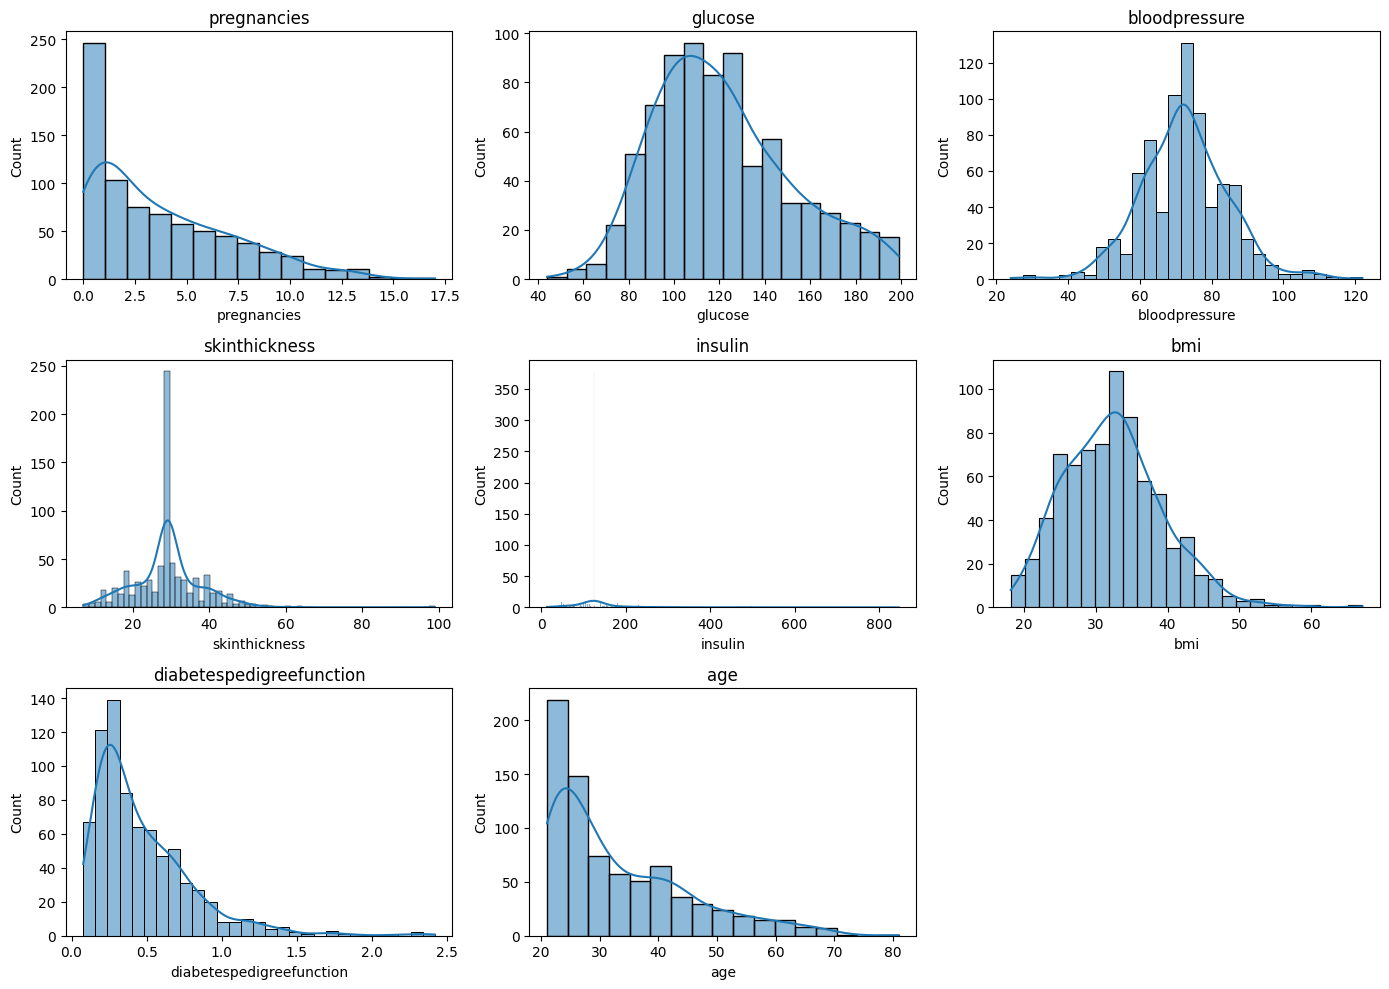

In [ ]:
plt.figure(figsize=(14,10))
for i, col in enumerate(df.columns[:-1]):
  plt.subplot(3,3,i+1)
  sns.histplot(df[col], kde=True)
  plt.title(col)
plt.tight_layout()
plt.show()

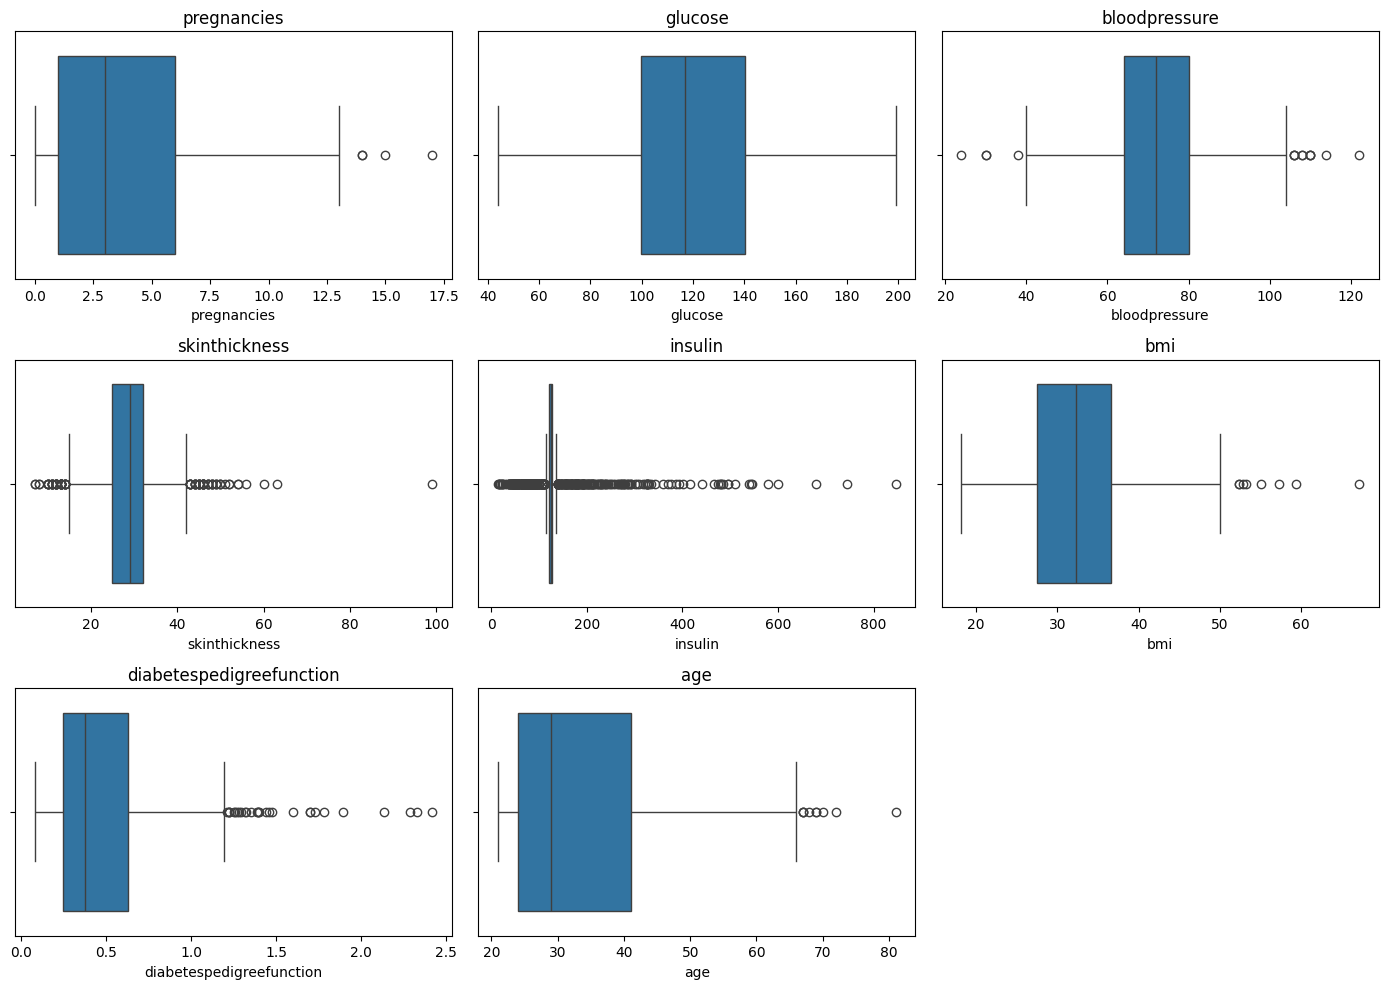

In [ ]:
plt.figure(figsize=(14,10))
for i, col in enumerate(df.columns[:-1]):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

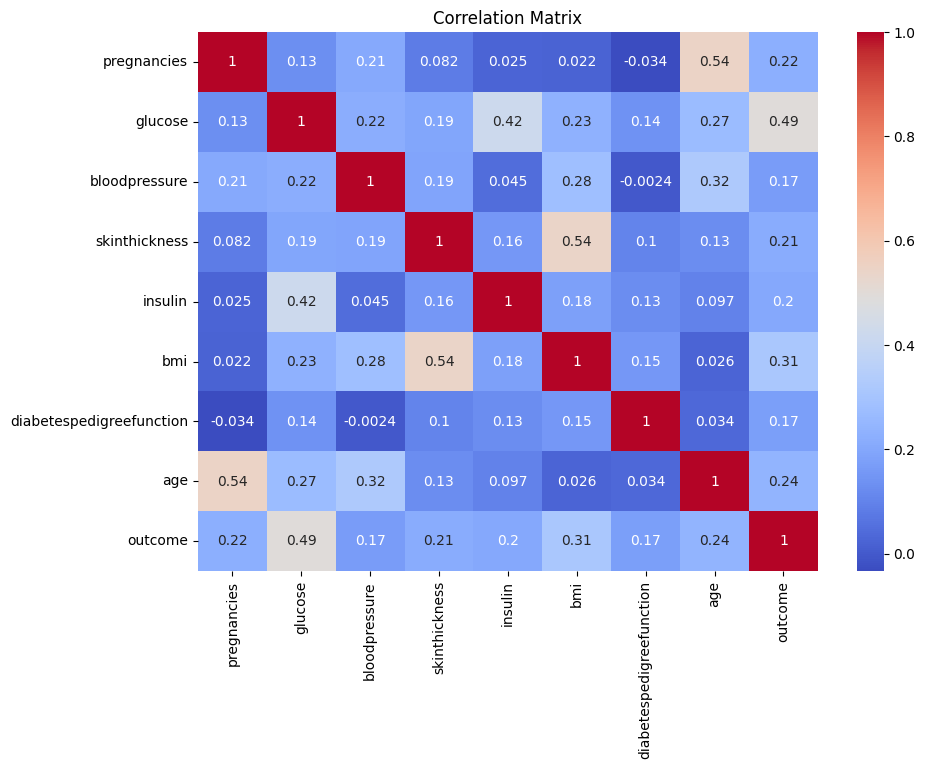

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 -Q1
df = df[(df['bmi']>Q1 - 1.5*IQR) & (df['bmi']<Q3 + 1.5*IQR)]

In [ ]:
df['bmi_AGE_Ratio'] = df['bmi'] / df['age']
df['glucose_bmi'] = df['glucose'] / df['bmi']
df['age_group'] = pd.cut(df['age'],bins=[20, 30, 40, 50 ,60,80],labels=[1,2,3,4,5])
df['age_group'] = df['age_group'].astype(float).fillna(99).astype(int)
x = df.drop('outcome',axis=1)
y = df['outcome']
x.columns


Index(['pregnancies', 'glucose', 'bloodpressure', 'skinthickness', 'insulin',
       'bmi', 'diabetespedigreefunction', 'age', 'bmi_AGE_Ratio',
       'glucose_bmi', 'Age_Group', 'Age_group', 'age_group'],
      dtype='object')

In [ ]:
scalar = StandardScaler()
x_scaled = scalar.fit_transform(x)

In [ ]:
from re import split
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(x_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\n Classification Report\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7697368421052632

 Classification Report

              precision    recall  f1-score   support

           0       0.79      0.86      0.83        96
           1       0.72      0.61      0.66        56

    accuracy                           0.77       152
   macro avg       0.76      0.74      0.74       152
weighted avg       0.77      0.77      0.76       152



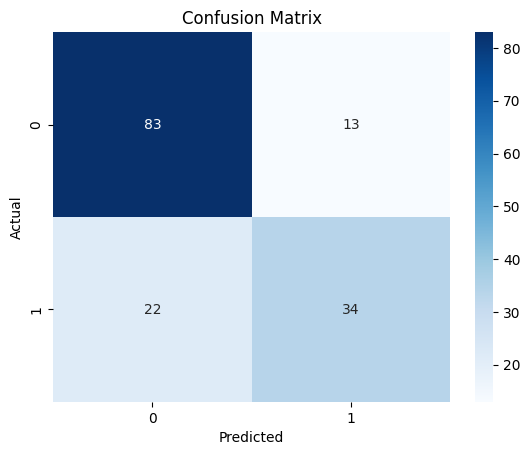

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',cmap='Blues' )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()